In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch.nn.functional as F


MODEL_NAME = "arnir0/Tiny-LLM"
#MODEL_NAME = "weiser/101M-0.4" 


In [337]:

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.config._attn_implementation = "eager"

Loading weights: 100%|██████████| 12/12 [00:00<00:00, 232.52it/s]


In [ ]:
model.save_pretrained("./" + MODEL_NAME)
tokenizer.save_pretrained("./"+MODEL_NAME+"_tokenizer")

In [342]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left" 

In [343]:
vocab = tokenizer.get_vocab()

In [344]:
print(vocab["ivan"])

20595


In [345]:
def generate_text(prompt, model, tokenizer, max_length=32, temperature=1, top_k=50, top_p=0.95):

    tokens = tokenizer.tokenize(prompt)
    print(tokens)

    ids = torch.tensor([tokenizer.convert_tokens_to_ids(tokens)])
    print(ids)

    inputs = tokenizer.encode(prompt, return_tensors="pt")
    print(input)

    outputs = model.generate(
        ids,
        max_length=max_length,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
        do_sample=True
    )


    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return generated_text

In [346]:
model


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 192)
    (layers): ModuleList(
      (0): LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=192, out_features=192, bias=False)
          (k_proj): Linear(in_features=192, out_features=96, bias=False)
          (v_proj): Linear(in_features=192, out_features=96, bias=False)
          (o_proj): Linear(in_features=192, out_features=192, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=192, out_features=1024, bias=False)
          (up_proj): Linear(in_features=192, out_features=1024, bias=False)
          (down_proj): Linear(in_features=1024, out_features=192, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((192,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((192,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((192,), eps=1e-05)
    (rotary_emb): LlamaRotaryEm

In [459]:
prompt = "i think that 2 x 2 equals to "

In [461]:
s = len(tokenizer.tokenize(prompt))
l = 1
generated_text = generate_text(prompt, model, tokenizer, s+l)

print("\n" + generated_text)

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


['▁i', '▁think', '▁that', '▁', '2', '▁x', '▁', '2', '▁equals', '▁to', '▁']
tensor([[  474,  1348,   393, 29871, 29906,   921, 29871, 29906, 15743,   304,
         29871]])
<bound method Kernel.raw_input of <ipykernel.ipkernel.IPythonKernel object at 0x10c7ea270>>

i think that 2 x 2 equals to 2


In [462]:
tokens = tokenizer.tokenize(prompt)
print(tokens)

ids = torch.tensor([tokenizer.convert_tokens_to_ids(tokens)])
print(ids)

print(tokenizer.encode(prompt, return_tensors="pt"))


['▁i', '▁think', '▁that', '▁', '2', '▁x', '▁', '2', '▁equals', '▁to', '▁']
tensor([[  474,  1348,   393, 29871, 29906,   921, 29871, 29906, 15743,   304,
         29871]])
tensor([[    1,   474,  1348,   393, 29871, 29906,   921, 29871, 29906, 15743,
           304, 29871]])


In [463]:
outputs = model(ids, 
                output_attentions=True,
                output_hidden_states=True,
                return_dict=True)

print(outputs)
attn = outputs.attentions[0]
print(attn[0][0])


CausalLMOutputWithPast(loss=None, logits=tensor([[[ -4.9328,  -4.9131,   4.0986,  ...,  -4.5852,  -4.7602,  -4.6154],
         [ -6.5063,  -6.4896,   4.0434,  ...,  -5.6100,  -6.4286,  -5.9517],
         [-10.9226, -10.9248,  -0.2742,  ..., -10.2936, -10.8424, -10.5389],
         ...,
         [-16.9741, -16.9502,  -0.3081,  ..., -14.2846, -16.4793, -14.5106],
         [-15.6503, -15.6351,  -3.0483,  ..., -13.3637, -15.2019, -13.7880],
         [ -8.6843,  -8.6758,   1.5806,  ...,  -6.8307,  -8.3648,  -7.1536]]],
       grad_fn=<UnsafeViewBackward0>), past_key_values=DynamicCache(layers=[DynamicLayer]), hidden_states=(tensor([[[-1.3321e-02,  4.6631e-02,  5.5313e-03,  ..., -4.1901e-02,
           3.2928e-02, -3.5004e-02],
         [ 1.6724e-02,  5.6305e-02, -5.5275e-03,  ..., -3.0624e-02,
           6.4331e-02,  1.6113e-02],
         [-1.2520e-02,  6.9580e-03, -3.6163e-02,  ...,  2.3544e-02,
           6.5979e-02, -7.4539e-03],
         ...,
         [ 1.4145e-02,  2.3727e-02, -1.1536e-

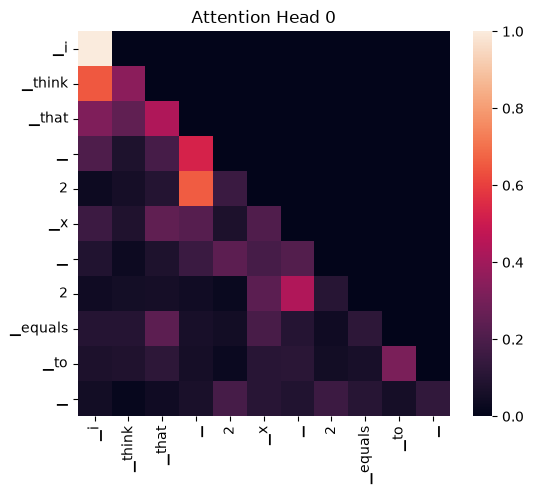

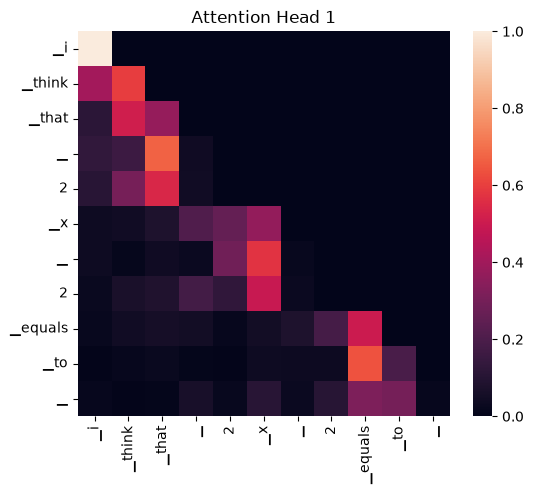

In [464]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# 1. Извлекаем все головы для первого батча и переводим в numpy
# Предварительно переносим на CPU и меняем тип, чтобы избежать ошибок
heads = attn[0].detach().cpu().to(torch.float32).numpy()

# 2. Получаем текстовые токены для осей
labels = tokenizer.convert_ids_to_tokens(ids[0])

# 3. Строим тепловую карту для каждой головы в цикле
for i, head_matrix in enumerate(heads):
    plt.figure(figsize=(6, 5))
    plt.title(f"Attention Head {i}")  # Добавлено для ясности, какая голова отображается
    sns.heatmap(head_matrix, xticklabels=labels, yticklabels=labels)
    plt.show()


In [412]:
hs = outputs.hidden_states
embs = hs[0]
l0 = hs[1]

In [ ]:
layer = model.model.layers[0]
x = embs
x_norm = layer.input_layernorm(x)

tensor([[[-0.0132,  0.0153,  0.0538,  ...,  0.0181,  0.0399, -0.0391],
         [ 0.0407,  0.0341, -0.0386,  ..., -0.0044,  0.0305,  0.0035],
         [-0.0123,  0.0378,  0.0024,  ..., -0.0029,  0.0721,  0.0057],
         ...,
         [ 0.0007,  0.0067, -0.0032,  ..., -0.0204,  0.0405,  0.0007],
         [ 0.0180,  0.0490, -0.0191,  ..., -0.0034,  0.0079,  0.0254],
         [ 0.0304,  0.0406, -0.0162,  ...,  0.0064,  0.0096,  0.0119]]],
       grad_fn=<EmbeddingBackward0>)
